# Análise de Evasão Escolar na Grande Vitória (ES)

Este projeto tem como objetivo analisar os fatores associados à evasão escolar no Ensino Médio na região da Grande Vitória (Vitória, Cariacica, Vila Velha e Serra), utilizando dados do INEP.

A proposta é identificar padrões e relações entre desempenho acadêmico, tipo de rede de ensino e taxas de abandono escolar, buscando compreender quais variáveis estão mais associadas à evasão.

Nesta MVP serão apresentadas as seguintes etapas:

- Análise exploratória dos dados (EDA), incluindo comparações entre níveis de ensino, municípios e tipos de escola
- Análise estatística, incluindo correlação de Pearson para investigação de relações entre variáveis
- Modelagem supervisionada, com Regressão Linear Múltipla para interpretação dos fatores associados à evasão
- Modelagem preditiva com Random Forest Regressor para captura de relações não lineares
- Avaliação e comparação de desempenho dos modelos por meio de métricas como R², MAE e RMSE


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)


Matplotlib is building the font cache; this may take a moment.


## Carregamento e Filtro Geográfico


In [3]:
cols_micro = ['CO_ENTIDADE', 'NO_MUNICIPIO', 'SG_UF', 'TP_DEPENDENCIA']
cidades = ['Vitória', 'Cariacica', 'Vila Velha', 'Serra']

try:
   df_micro = pd.read_csv('microdados_ed_basica_2024.csv', sep=';', encoding='latin1', usecols=cols_micro )
   df_es = df_micro[(df_micro['SG_UF'] == 'ES') & (df_micro['NO_MUNICIPIO'].isin(cidades))].copy()

   df_tx = pd.read_excel('tx_rend_escolas_2024.xlsx', skiprows=8)
   df_tx.columns = [c.strip() for c in df_tx.columns]

   df_tx['CO_ENTIDADE'] = df_tx['CO_ENTIDADE'].astype(str).str.split('.').str[0]
   df_es['CO_ENTIDADE'] = df_es['CO_ENTIDADE'].astype(str).str.split('.').str[0]

   df_final = pd.merge(df_es, df_tx, on='CO_ENTIDADE', how='inner')
        
   if df_final.empty:
           print("Atenção: O merge resultou em um dataframe vazio. Verifique os códigos das escolas.")
   else:
           print(f"Sucesso! {len(df_final)} escolas da Grande Vitória encontradas.")

except Exception as e:
    print(f"Erro ao processar: {e}")

Sucesso! 514 escolas da Grande Vitória encontradas.


## Conjunto de Dados Macro

In [4]:
print(df_final.head())

  SG_UF_x NO_MUNICIPIO_x CO_ENTIDADE  TP_DEPENDENCIA NU_ANO_CENSO NO_REGIAO  \
0      ES      Cariacica    32033656               3         2024   Sudeste   
1      ES      Cariacica    32033729               3         2024   Sudeste   
2      ES      Cariacica    32033745               2         2024   Sudeste   
3      ES      Cariacica    32033770               3         2024   Sudeste   
4      ES      Cariacica    32033796               2         2024   Sudeste   

  SG_UF_y  CO_MUNICIPIO NO_MUNICIPIO_y                            NO_ENTIDADE  \
0      ES     3201308.0      Cariacica    EMEF LAURINDA PEREIRA DO NASCIMENTO   
1      ES     3201308.0      Cariacica         EMEF ANTONIO COUTINHO OLIVEIRA   
2      ES     3201308.0      Cariacica                EEEFM CEL OLIMPIO CUNHA   
3      ES     3201308.0      Cariacica                EMEF ELISA LEAL BEZERRA   
4      ES     3201308.0      Cariacica  EEEFM MARIA DE LOURDES POYARES LABUTO   

   ... 3_CAT_FUN_06 3_CAT_FUN_07 3_CAT

In [5]:
df_final.shape

(514, 66)

In [6]:
print(df_final.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 514 entries, 0 to 513
Data columns (total 66 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   SG_UF_x         514 non-null    object 
 1   NO_MUNICIPIO_x  514 non-null    object 
 2   CO_ENTIDADE     514 non-null    object 
 3   TP_DEPENDENCIA  514 non-null    int64  
 4   NU_ANO_CENSO    514 non-null    object 
 5   NO_REGIAO       514 non-null    object 
 6   SG_UF_y         514 non-null    object 
 7   CO_MUNICIPIO    514 non-null    float64
 8   NO_MUNICIPIO_y  514 non-null    object 
 9   NO_ENTIDADE     514 non-null    object 
 10  NO_CATEGORIA    514 non-null    object 
 11  NO_DEPENDENCIA  514 non-null    object 
 12  1_CAT_FUN       514 non-null    object 
 13  1_CAT_FUN_AI    514 non-null    object 
 14  1_CAT_FUN_AF    514 non-null    object 
 15  1_CAT_FUN_01    514 non-null    object 
 16  1_CAT_FUN_02    514 non-null    object 
 17  1_CAT_FUN_03    514 non-null    obj

## Verificação de dados nulos

In [7]:
print(df_final.isnull().sum())

SG_UF_x           0
NO_MUNICIPIO_x    0
CO_ENTIDADE       0
TP_DEPENDENCIA    0
NU_ANO_CENSO      0
                 ..
3_CAT_MED_01      0
3_CAT_MED_02      0
3_CAT_MED_03      0
3_CAT_MED_04      0
3_CAT_MED_NS      0
Length: 66, dtype: int64


## Calculando as taxas de Abandono por Nível de Ensino

In [8]:
cols_abandono_fund = [f'3_CAT_FUN_{i:02d}' for i in range(1, 10)]
cols_abandono_med = [f'3_CAT_MED_{i:02d}' for i in range(1, 4)]

df_final[cols_abandono_fund] = df_final[cols_abandono_fund].apply(
    pd.to_numeric,
    errors='coerce'
)

df_final[cols_abandono_med] = df_final[cols_abandono_med].apply(
    pd.to_numeric,
    errors='coerce'
)

In [9]:
media_fund = df_final[cols_abandono_fund].stack().mean()
media_med = df_final[cols_abandono_med].stack().mean()

print(f"Média de abandono do Fundamental: {media_fund:.2f}")
print(f"Média de abandono do Médio: {media_med:.2f}")

Média de abandono do Fundamental: 0.21
Média de abandono do Médio: 1.13


## Correlação do Abandono com o Município

In [10]:
cols_abandono = cols_abandono_fund + cols_abandono_med

df_final['taxa_abandono_total'] = df_final[cols_abandono].mean(axis=1)

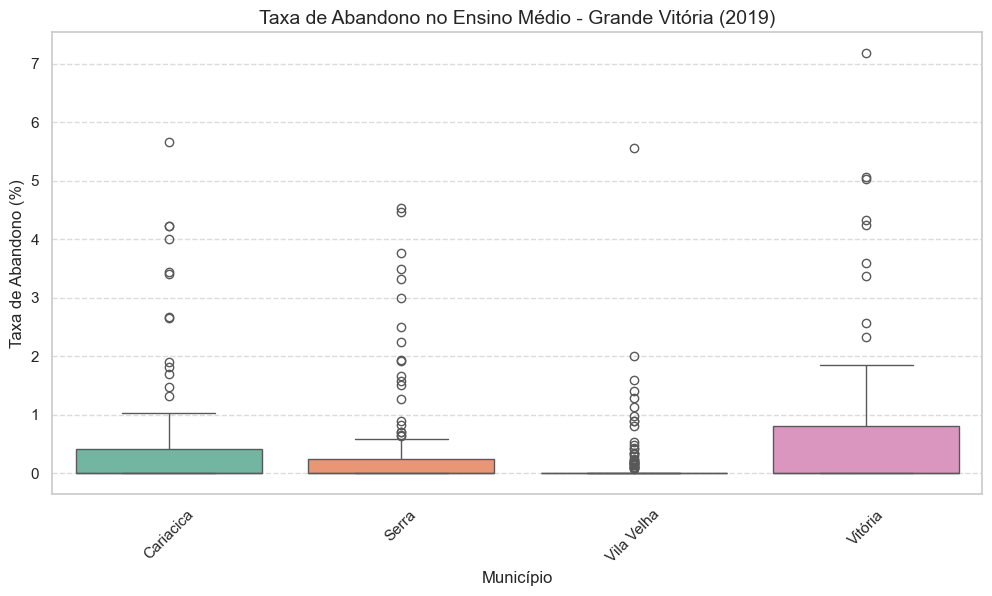

In [11]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df_final, 
            x='NO_MUNICIPIO_x', 
            y='taxa_abandono_total', 
            hue='NO_MUNICIPIO_x', 
            palette="Set2", 
            legend=False          
)

plt.title('Taxa de Abandono no Ensino Médio - Grande Vitória (2019)', fontsize=14)
plt.ylabel('Taxa de Abandono (%)')
plt.xlabel('Município')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

### Comparação da Taxa de Abandono: Fundamental x Médio

In [12]:
df_final['taxa_abandono_fund'] = df_final[cols_abandono_fund].mean(axis=1)
df_final['taxa_abandono_med'] = df_final[cols_abandono_med].mean(axis=1)

comparativo_medias = df_final.groupby('NO_MUNICIPIO_x')[['taxa_abandono_fund', 'taxa_abandono_med']].mean()
print("Média de Abandono por Etapa e Município:")
display(comparativo_medias)

Média de Abandono por Etapa e Município:


,taxa_abandono_fund,taxa_abandono_med
NO_MUNICIPIO_x,,
Cariacica,0.320548,1.443333
Serra,0.161551,1.462037
Vila Velha,0.090769,0.454861
Vitória,0.362966,1.318095


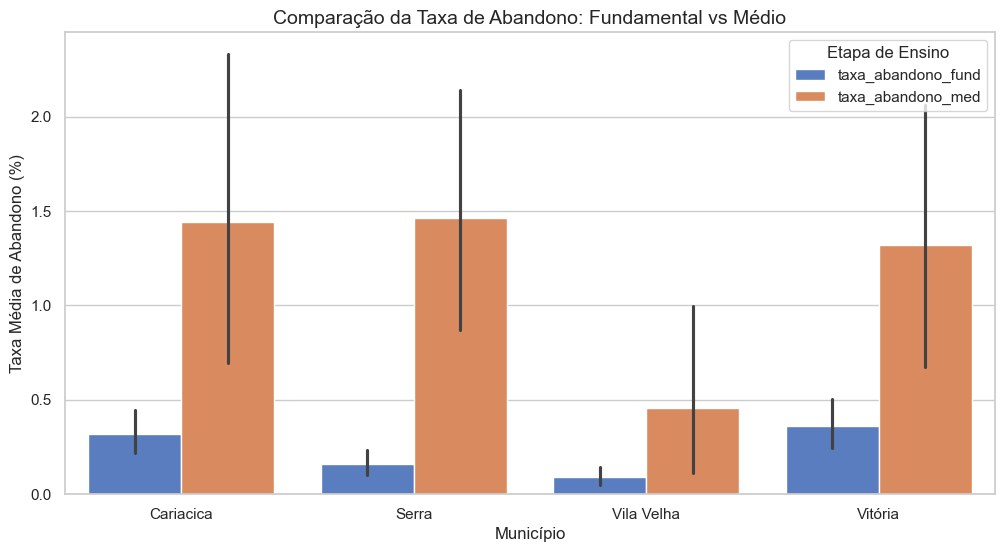

In [13]:
df_melted = df_final.melt(id_vars=['NO_MUNICIPIO_x'], 
                         value_vars=['taxa_abandono_fund', 'taxa_abandono_med'],
                         var_name='Etapa', value_name='Taxa_Abandono')

plt.figure(figsize=(12, 6))
sns.barplot(data=df_melted, x='NO_MUNICIPIO_x', y='Taxa_Abandono', hue='Etapa', palette='muted')

plt.title('Comparação da Taxa de Abandono: Fundamental vs Médio', fontsize=14)
plt.ylabel('Taxa Média de Abandono (%)')
plt.xlabel('Município')
plt.legend(title='Etapa de Ensino')
plt.show()

No geral, a taxa média de abandono no ensino médio (1,13%) é aproximadamente 5,4 vezes maior que a observada no ensino fundamental (0,21%).

Isso pode estar associado a fatores como:
- entrada precoce no mercado de trabalho
- desmotivação com o modelo educacional
- aumento da dificuldade acadêmica

O Ensino Médio deve ser tratado como etapa crítica para políticas de permanência escolar.

## Fatores de Desempenho Escolar x Evasão

In [14]:
cols_aprovacao_fund = [f'1_CAT_FUN_{i:02d}' for i in range(1, 10)]
cols_aprovacao_med = [f'1_CAT_MED_{i:02d}' for i in range(1, 4)]

df_final[cols_aprovacao_fund] = df_final[cols_aprovacao_fund].apply(
    pd.to_numeric,
    errors='coerce'
)

df_final[cols_aprovacao_med] = df_final[cols_aprovacao_med].apply(
    pd.to_numeric,
    errors='coerce'
)

cols_aprovacao = cols_aprovacao_fund + cols_aprovacao_med

df_final['taxa_aprovacao_total'] = df_final[cols_aprovacao].mean(axis=1)

### Correlação de Pearson entre a Taxa de Aprovação e a Taxa de Abandono

In [15]:
df_final[['taxa_aprovacao_total', 'taxa_abandono_total']].corr()

,taxa_aprovacao_total,taxa_abandono_total
taxa_aprovacao_total,1.000000,-0.414763
taxa_abandono_total,-0.414763,1.000000


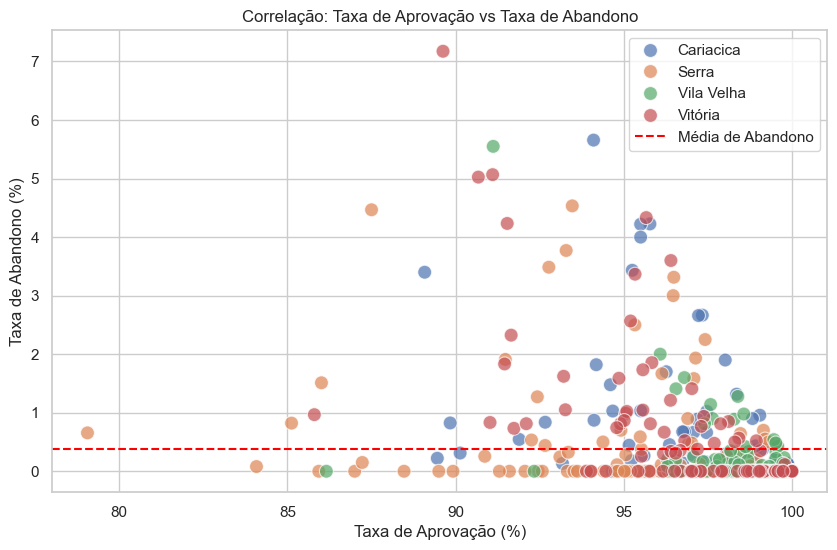

In [16]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_final, x='taxa_aprovacao_total', y='taxa_abandono_total', hue='NO_MUNICIPIO_x', s=100, alpha=0.7)
plt.title('Correlação: Taxa de Aprovação vs Taxa de Abandono')
plt.xlabel('Taxa de Aprovação (%)')
plt.ylabel('Taxa de Abandono (%)')
plt.axhline(df_final['taxa_abandono_total'].mean(), color='red', linestyle='--', label='Média de Abandono')
plt.legend()
plt.show()

Existe uma correlação negativa moderada entre aprovação e evasão. Em geral, municípios com maiores taxas de aprovação tendem a apresentar menores taxas de abandono escolar,  indicando que dificuldades de aprendizagem podem desestimular os alunos, consequentemente, à maior probabilidade de evasão escolar.

## Proporção de Abandono por tipo de escola 

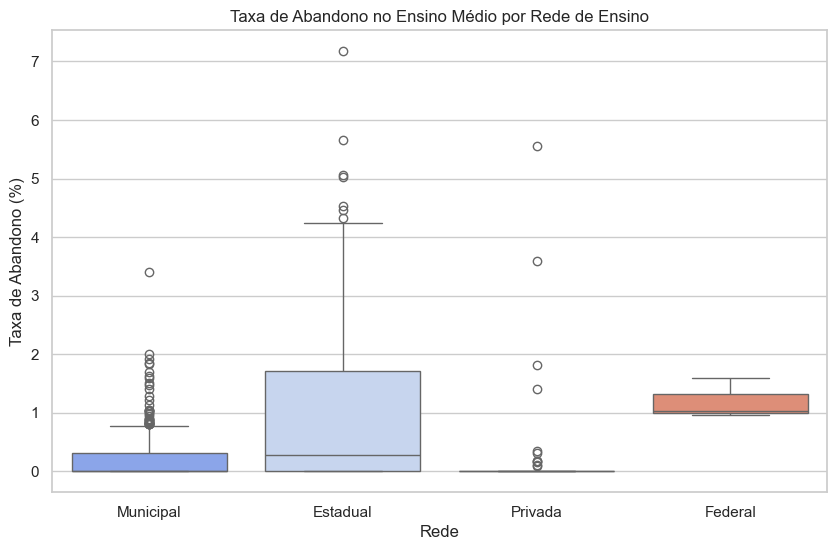

In [17]:
dict_dep = {1: 'Federal', 2: 'Estadual', 3: 'Municipal', 4: 'Privada'}
df_final['Rede'] = df_final['TP_DEPENDENCIA'].map(dict_dep)

plt.figure(figsize=(10, 6))
sns.boxplot(data=df_final, x='Rede', y='taxa_abandono_total', hue='Rede', palette='coolwarm', legend=False)
plt.title('Taxa de Abandono no Ensino Médio por Rede de Ensino')
plt.ylabel('Taxa de Abandono (%)')
plt.show()

Escolas públicas apresentam maior variabilidade e, em geral, maiores taxas de abandono em comparação às escolas privadas.

Isso pode refletir desigualdades socioeconômicas, onde alunos da rede pública enfrentam maiores desafios, como:
- necessidade de trabalhar
- menor apoio familiar
- menor acesso a recursos educacionais